In [2]:
import pandas as pd
import os
from typing import Iterator, Generator, List, Dict

# --- Constantes ---
CSV_FILE_PATH = None
CHUNK_SIZE = 100000  # Définir une taille de morceau (par exemple, 100 000 lignes)

def process_csv_by_chunks(path: str, chunk_size: int) -> List[pd.DataFrame] | None:
    """
    Charge un fichier CSV par morceaux, traite chaque morceau,
    et retourne une liste des DataFrames traités.

    Args:
        path (str): Le chemin vers le fichier CSV.
        chunk_size (int): Le nombre de lignes à lire à la fois.

    Returns:
        List[pd.DataFrame] | None: Une liste des DataFrames traités, ou None en cas d'erreur.
    """

    print(f"Tentative de chargement du fichier : {os.path.abspath(path)}")
    print(f"Chargement par morceaux de taille : {chunk_size} lignes.")

    if not os.path.exists(path):
        print(f"Erreur: Le fichier '{path}' est introuvable. Vérifiez le chemin d'accès.")
        return None

    processed_chunks = []
    chunk_index = 0

    try:
        # Créer un itérateur (TextFileReader) au lieu d'un DataFrame unique
        csv_iterator = pd.read_csv(path, chunksize=chunk_size)

        # Parcourir les morceaux générés par l'itérateur
        for chunk in csv_iterator:
            chunk_index += 1
            print(f"Traitement du morceau #{chunk_index} (taille: {len(chunk)} lignes)...")

            # 💡 --- Zone de Traitement des Données --- 💡
            # Ici, vous pouvez appliquer des opérations qui réduisent la taille du morceau,
            # comme le filtrage, l'agrégation ou le calcul de statistiques.

            # Exemple : Calculer la moyenne de toutes les colonnes et stocker
            # stats_df = chunk.mean().to_frame().T
            # processed_chunks.append(stats_df)

            # Exemple : Filtrer pour garder uniquement les lignes où 'col_A' > 10
            # filtered_chunk = chunk[chunk['col_A'] > 10]
            # processed_chunks.append(filtered_chunk)

            # --- Fin de la Zone de Traitement ---

            # Dans cet exemple, nous stockons le morceau complet filtré
            # Si vous avez 500Mo, vous DEVEZ faire un traitement pour réduire le morceau avant de l'ajouter
            # à 'processed_chunks', sinon vous resaturerez votre RAM.
            processed_chunks.append(chunk)


        print(f"\nChargement et traitement terminés. {chunk_index} morceaux traités.")

        # ⚠️ ATTENTION : La ligne suivante va CONSOLIDER TOUS les morceaux.
        # Si vous n'avez pas réduit la taille des morceaux, vous risquez une saturation RAM.
        # Si vous n'avez besoin que de statistiques, vous pouvez retourner processed_chunks directement.
        final_dataframe = pd.concat(processed_chunks, ignore_index=True)
        print(f"Taille du DataFrame final: {len(final_dataframe)} lignes.")
        return final_dataframe

    except Exception as e:
        print(f"Une erreur s'est produite lors du traitement du fichier CSV : {e}")
        return None

In [3]:
import pandas as pd
import os
from typing import Iterator, Generator, List, Dict

import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler


# --- Constantes ---
CSV_FILE_PATH = None
CHUNK_SIZE = 100000  # Définir une taille de morceau (par exemple, 100 000 lignes)

def process_csv_by_chunks_n(path: str, chunk_size: int, sample_size=1) -> List[pd.DataFrame] | None:
    """
    Charge un fichier CSV par morceaux, traite chaque morceau,
    et retourne une liste des DataFrames traités.

    Args:
        path (str): Le chemin vers le fichier CSV.
        chunk_size (int): Le nombre de lignes à lire à la fois.

    Returns:
        List[pd.DataFrame] | None: Une liste des DataFrames traités, ou None en cas d'erreur.
    """

    print(f"Tentative de chargement du fichier : {os.path.abspath(path)}")
    print(f"Chargement par morceaux de taille : {chunk_size} lignes.")

    if not os.path.exists(path):
        print(f"Erreur: Le fichier '{path}' est introuvable. Vérifiez le chemin d'accès.")
        return None

    processed_chunks = []
    chunk_index = 0

    try:
        # Créer un itérateur (TextFileReader) au lieu d'un DataFrame unique
        csv_iterator = pd.read_csv(path, chunksize=chunk_size)

        # Parcourir les morceaux générés par l'itérateur
        for chunk in csv_iterator:
            chunk_index += 1
            print(f"Traitement du morceau #{chunk_index} (taille: {len(chunk)} lignes)...")

            # 💡 --- Zone de Traitement des Données --- 💡
            # Ici, vous pouvez appliquer des opérations qui réduisent la taille du morceau,
            # comme le filtrage, l'agrégation ou le calcul de statistiques.

            # Exemple : Calculer la moyenne de toutes les colonnes et stocker
            # stats_df = chunk.mean().to_frame().T
            # processed_chunks.append(stats_df)

            # Exemple : Filtrer pour garder uniquement les lignes où 'col_A' > 10
            # filtered_chunk = chunk[chunk['col_A'] > 10]
            # processed_chunks.append(filtered_chunk)

            # --- Fin de la Zone de Traitement ---

            # Dans cet exemple, nous stockons le morceau complet filtré
            # Si vous avez 500Mo, vous DEVEZ faire un traitement pour réduire le morceau avant de l'ajouter
            # à 'processed_chunks', sinon vous resaturerez votre RAM.
            chunk = chunk.iloc[::sample_size,:]
            processed_chunks.append(chunk)


        print(f"\nChargement et traitement terminés. {chunk_index} morceaux traités.")

        # ⚠️ ATTENTION : La ligne suivante va CONSOLIDER TOUS les morceaux.
        # Si vous n'avez pas réduit la taille des morceaux, vous risquez une saturation RAM.
        # Si vous n'avez besoin que de statistiques, vous pouvez retourner processed_chunks directement.
        final_dataframe = pd.concat(processed_chunks, ignore_index=True)
        print(f"Taille du DataFrame final: {len(final_dataframe)} lignes.")
        return final_dataframe

    except Exception as e:
        print(f"Une erreur s'est produite lors du traitement du fichier CSV : {e}")
        return None

In [4]:
import sys
sys.path.append('..')


F_train = pd.read_csv("../data/raw_data/TEP_Faulty_Training.csv").iloc[::10]


In [20]:
F_train['sample'].nunique()

50

In [8]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler


X = F_train.drop(columns=['faultNumber', 'simulationRun', 'sample']) # Drop simulationRun and sample if they are not features
# 20 classes
y = F_train['faultNumber']
# 2. Préparation de la validation croisée
tscv = TimeSeriesSplit(n_splits=5)
print(f"Shape globale : {X.shape}")
# 3. Boucle d'entraînement
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"\n--- Fold {fold+1} ---")
    # A. Découpage
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # B. Normalisation (L'étape critique avec 52 features)
    # On doit aplatir les données pour le scaler : (N_seq * Time, Features)
    # Cela permet de normaliser chaque feature indépendamment du temps
    num_features = X_train.shape[1]        # Number of features
    timesteps_per_sequence = 50 # Assuming 500 timesteps per sequence. PLEASE VERIFY.
    # Ensure training set has complete sequences by trimming excess rows
    num_rows_train_fold = X_train.shape[0]
    remainder_train = num_rows_train_fold % timesteps_per_sequence
    if remainder_train != 0:
        print(f"Warning: Trimming {remainder_train} rows from training set to ensure complete sequences.")
        X_train = X_train.iloc[:-remainder_train]
        y_train = y_train.iloc[:-remainder_train]
        num_rows_train_fold = X_train.shape[0]
    num_sequences_train_fold = num_rows_train_fold // timesteps_per_sequence
    # Ensure test set has complete sequences by trimming excess rows
    num_rows_test_fold = X_test.shape[0]
    remainder_test = num_rows_test_fold % timesteps_per_sequence
    if remainder_test != 0:
        print(f"Warning: Trimming {remainder_test} rows from test set to ensure complete sequences.")
        X_test = X_test.iloc[:-remainder_test]
        y_test = y_test.iloc[:-remainder_test]
        num_rows_test_fold = X_test.shape[0]
    num_sequences_test_fold = num_rows_test_fold // timesteps_per_sequence
    # Convert DataFrames to NumPy arrays before scaling and reshaping
    X_train_np = X_train.values
    X_test_np = X_test.values
    scaler = StandardScaler()
    # FIT only on TRAIN! The data is already in 2D (num_rows, num_features) for scaling.
    X_train_scaled_2d = scaler.fit_transform(X_train_np)
    # TRANSFORM on TEST (using stats from train)
    X_test_scaled_2d = scaler.transform(X_test_np)
y_train_seq = y_train.iloc[::timesteps_per_sequence] - 1
y_test_seq = y_test.iloc[::timesteps_per_sequence] - 1
# Return to 3D for the RNN: (num_sequences, timesteps_per_sequence, num_features)
X_train_final = X_train_scaled_2d.reshape(num_sequences_train_fold, timesteps_per_sequence, num_features)
X_test_final = X_test_scaled_2d.reshape(num_sequences_test_fold, timesteps_per_sequence, num_features)
print(f"Train shape: {X_train_final.shape}")
print(f"Test shape:  {X_test_final.shape}")
# C. Entraînement du modèle (Exemple Keras/TensorFlow)
# model = create_rnn_model(input_shape=(500, 52), num_classes=20)
# model.fit(X_train_final, y_train, validation_data=(X_test_final, y_test)...)


Shape globale : (500000, 52)

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---
Train shape: (8333, 50, 52)
Test shape:  (1666, 50, 52)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import numpy as np # Added numpy import


n_time = 50
n_feat = 52

y_train_seq = y_train.iloc[::n_time] - 1
y_test_seq = y_test.iloc[::n_time] - 1

print("\n" + "="*60)
print("ENTRAÎNEMENT DU MODÈLE CNN")
print("="*60)


model = Sequential([
    layers.Input(shape=(n_time, n_feat)),
    layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(512, kernel_size=1, activation='relu', padding='same'),
    layers.BatchNormalization(),
    # layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(21, activation='softmax')
])
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
        X_train_final, y_train_seq, # Use y_train_seq
        validation_data=(X_test_final, y_test_seq), # Use y_test_seq
        epochs=50,
        batch_size=32,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
        ])
# ====================================
# 4. ÉVALUATION
# ====================================

test_loss, test_acc = model.evaluate(X_test_final, y_test_seq, verbose=0) # Use y_test_seq
print(f"\nTEST ACCURACY : {test_acc:.4f}")

y_prob = model.predict(X_test_final, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Adjust class_labels and class_names for 0-indexed labels and proper display
class_labels = sorted(np.unique(y_test_seq)) # These will be 0-19
class_names = [f"Panne_{label+1}" for label in class_labels] # Map 0->Panne_1, 1->Panne_2, etc.

from sklearn.metrics import classification_report
print("\n" + classification_report(
    y_test_seq, y_pred, # Use y_test_seq
    labels=class_labels,
    target_names=class_names,
    zero_division=0
))



ENTRAÎNEMENT DU MODÈLE CNN


2025-12-09 16:01:10.608101: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-12-09 16:01:10.608149: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-09 16:01:10.608155: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-12-09 16:01:10.608476: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-09 16:01:10.608620: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2025-12-09 16:01:11.752567: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-12-09 16:01:11.871650: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


261/261 [==============================] - 7s 19ms/step - loss: 2.8940 - accuracy: 0.6273 - val_loss: 6.9104 - val_accuracy: 0.4730 - lr: 0.0010
Epoch 2/50
261/261 [==============================] - 4s 17ms/step - loss: 2.2105 - accuracy: 0.7554 - val_loss: 6.3130 - val_accuracy: 0.5732 - lr: 0.0010
Epoch 3/50
261/261 [==============================] - 4s 17ms/step - loss: 2.0648 - accuracy: 0.7967 - val_loss: 13.6416 - val_accuracy: 0.5348 - lr: 0.0010
Epoch 4/50
261/261 [==============================] - 4s 17ms/step - loss: 2.5297 - accuracy: 0.7986 - val_loss: 12.9391 - val_accuracy: 0.5906 - lr: 0.0010
Epoch 5/50
261/261 [==============================] - 4s 17ms/step - loss: 1.7911 - accuracy: 0.8291 - val_loss: 15.2804 - val_accuracy: 0.6747 - lr: 0.0010
Epoch 6/50
261/261 [==============================] - 4s 17ms/step - loss: 2.8896 - accuracy: 0.8112 - val_loss: 40.1761 - val_accuracy: 0.5330 - lr: 0.0010
Epoch 7/50
261/261 [==============================] - 4s 17ms/step - lo

In [10]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

def preproc(df):
    X = df.drop(columns=['faultNumber', 'simulationRun', 'sample']) # Drop simulationRun and sample if they are not features
    # 20 classes
    y = df['faultNumber']
    # 2. Préparation de la validation croisée
    tscv = TimeSeriesSplit(n_splits=5)
    print(f"Shape globale : {X.shape}")
    # 3. Boucle d'entraînement
    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
        print(f"\n--- Fold {fold+1} ---")
        # A. Découpage
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        # B. Normalisation (L'étape critique avec 52 features)
        # On doit aplatir les données pour le scaler : (N_seq * Time, Features)
        # Cela permet de normaliser chaque feature indépendamment du temps
        num_features = X_train.shape[1]        # Number of features
        timesteps_per_sequence = 50 # Assuming 500 timesteps per sequence. PLEASE VERIFY.
        # Ensure training set has complete sequences by trimming excess rows
        num_rows_train_fold = X_train.shape[0]
        remainder_train = num_rows_train_fold % timesteps_per_sequence
        if remainder_train != 0:
            print(f"Warning: Trimming {remainder_train} rows from training set to ensure complete sequences.")
            X_train = X_train.iloc[:-remainder_train]
            y_train = y_train.iloc[:-remainder_train]
            num_rows_train_fold = X_train.shape[0]
        num_sequences_train_fold = num_rows_train_fold // timesteps_per_sequence
        # Ensure test set has complete sequences by trimming excess rows
        num_rows_test_fold = X_test.shape[0]
        remainder_test = num_rows_test_fold % timesteps_per_sequence
        if remainder_test != 0:
            print(f"Warning: Trimming {remainder_test} rows from test set to ensure complete sequences.")
            X_test = X_test.iloc[:-remainder_test]
            y_test = y_test.iloc[:-remainder_test]
            num_rows_test_fold = X_test.shape[0]
        num_sequences_test_fold = num_rows_test_fold // timesteps_per_sequence
        # Convert DataFrames to NumPy arrays before scaling and reshaping
        X_train_np = X_train.values
        X_test_np = X_test.values
        scaler = StandardScaler()
        # FIT only on TRAIN! The data is already in 2D (num_rows, num_features) for scaling.
        X_train_scaled_2d = scaler.fit_transform(X_train_np)
        # TRANSFORM on TEST (using stats from train)
        X_test_scaled_2d = scaler.transform(X_test_np)
    y_train_seq = y_train.iloc[::timesteps_per_sequence] - 1
    y_test_seq = y_test.iloc[::timesteps_per_sequence] - 1
    # Return to 3D for the RNN: (num_sequences, timesteps_per_sequence, num_features)
    X_train_final = X_train_scaled_2d.reshape(num_sequences_train_fold, timesteps_per_sequence, num_features)
    X_test_final = X_test_scaled_2d.reshape(num_sequences_test_fold, timesteps_per_sequence, num_features)
    print(f"Train shape: {X_train_final.shape}")
    print(f"Test shape:  {X_test_final.shape}")
    # C. Entraînement du modèle (Exemple Keras/TensorFlow)
    # model = create_rnn_model(input_shape=(500, 52), num_classes=20)
    # model.fit(X_train_final, y_train, validation_data=(X_test_final, y_test)...)
    return X_train_final, X_test_final, y_train_seq, y_test_seq


Confusion Matrix CNN:
 [[70  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0 77  0  0  0]
 [ 0  0 11  2  0  0  0  2  2  0 46  0  0  0 20  0  0  0  0  0]
 [ 0  0  0 75  0  0  0  1  0  0  5  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 40  0  0  1 39  0  1  0  0  0  2  0  0  0  0  0]
 [ 0  0  0  0  0 16  0  0  0  0  0  2 48  1  0  0  1 15  0  0]
 [ 0  0 32 17  2  0 13  6  3  0  0  2  0  0  4  3  0  1  0  0]
 [ 0  0  3  0  0  0  0 61  0  3  1  0  9  0  4  1  0  0  1  0]
 [ 0  0  9  0  0  0  0  2 32  0 11  0  0  0 29  0  0  0  0  0]
 [ 0  0  2  0  2  0  0  2 23  5 29  0  0  0 12  8  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  2 59 15  0  0  0  0  0  0  7  0]
 [ 0  0  0  0  0  0  0  0  0  0  1 82  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  0  0 81  1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  5  0  0 78  0  0  0  0  1  0]
 [ 0  0 13  0  0  0  0  3 29  0 12  0  0  0 27  0  0  0  0  0]
 [ 0  0 41  0  0  0  0  2 17  3 

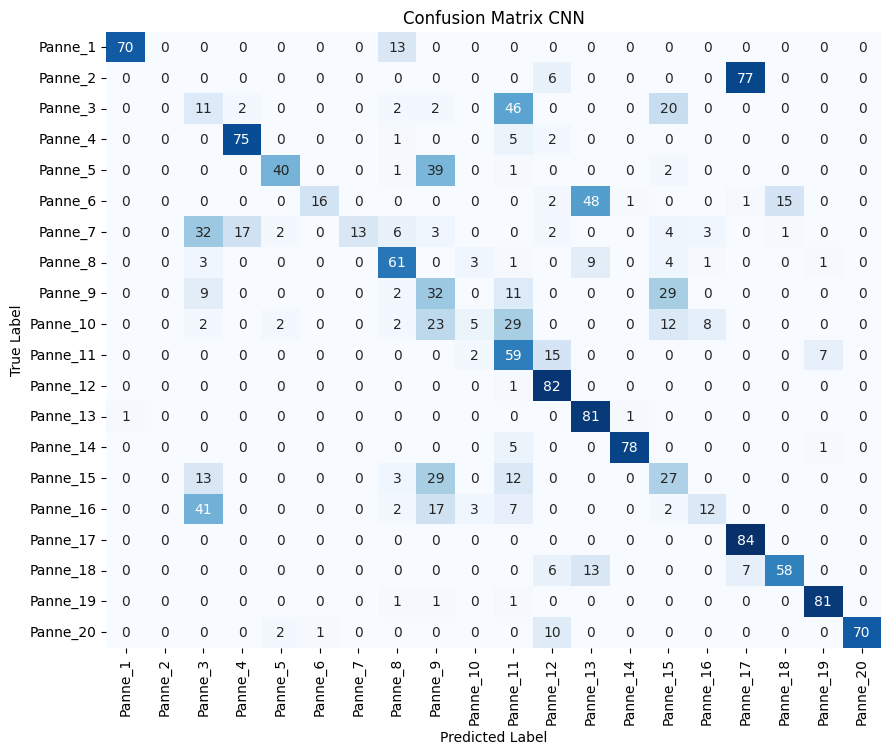

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_seq, y_pred)
print("Confusion Matrix CNN:\n", cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[f"Panne_{i+1}" for i in range(20)],
            yticklabels=[f"Panne_{i+1}" for i in range(20)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix CNN')
plt.show()

In [12]:
X_train, X_test, y_train, y_test = preproc(F_train)

Shape globale : (500000, 52)

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---
Train shape: (8333, 50, 52)
Test shape:  (1666, 50, 52)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import numpy as np # Added numpy import
from sklearn.metrics import classification_report


def model_CNN_test(X_train, y_test):
    model = Sequential([
        layers.Input(shape=(n_time, n_feat)),
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(512, kernel_size=1, activation='relu', padding='same'),
        layers.BatchNormalization(),
        # layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(21, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
            X_train, y_train, # Use y_train_seq
            validation_split=0.2, # Use y_test_seq
            epochs=25,
            batch_size=32,
            callbacks=[
                keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
            ])
    return model


In [37]:
def eval_test(X_test, y_test):

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0) # Use y_test_seq
    print(f"\nTEST ACCURACY : {test_acc:.4f}")

    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)


    print(classification_report(
        y_test, y_pred,
        labels=class_labels,
        target_names=class_names,
        zero_division=0
    ))
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix CNN:\n", cm)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[f"Panne_{i+1}" for i in range(20)],
            yticklabels=[f"Panne_{i+1}" for i in range(20)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix CNN')
    plt.show()

    return y_test, y_pred

In [30]:
X_train, X_test, y_train, y_test = preproc(F_train)

Shape globale : (500000, 52)

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---
Train shape: (8333, 50, 52)
Test shape:  (1666, 50, 52)


In [31]:
model = model_CNN_test(X_train, y_train)

Epoch 1/25
209/209 [==============================] - 6s 23ms/step - loss: 3.2038 - accuracy: 0.6088 - val_loss: 1.0239 - val_accuracy: 0.7475 - lr: 0.0010
Epoch 2/25
209/209 [==============================] - 4s 20ms/step - loss: 2.4883 - accuracy: 0.7363 - val_loss: 0.5304 - val_accuracy: 0.8194 - lr: 0.0010
Epoch 3/25
209/209 [==============================] - 4s 18ms/step - loss: 2.3778 - accuracy: 0.7738 - val_loss: 0.9565 - val_accuracy: 0.8236 - lr: 0.0010
Epoch 4/25
209/209 [==============================] - 4s 17ms/step - loss: 2.4738 - accuracy: 0.7907 - val_loss: 0.9934 - val_accuracy: 0.8314 - lr: 0.0010
Epoch 5/25
209/209 [==============================] - 4s 17ms/step - loss: 2.4260 - accuracy: 0.8005 - val_loss: 0.9144 - val_accuracy: 0.8542 - lr: 0.0010
Epoch 6/25
209/209 [==============================] - 4s 17ms/step - loss: 2.1342 - accuracy: 0.8173 - val_loss: 1.0713 - val_accuracy: 0.8470 - lr: 0.0010
Epoch 7/25
209/209 [==============================] - 4s 17ms/st


TEST ACCURACY : 0.7011
              precision    recall  f1-score   support

     Panne_1       1.00      1.00      1.00        83
     Panne_2       1.00      1.00      1.00        83
     Panne_3       0.00      0.00      0.00        83
     Panne_4       1.00      1.00      1.00        83
     Panne_5       0.00      0.00      0.00        83
     Panne_6       0.99      1.00      0.99        83
     Panne_7       0.00      0.00      0.00        83
     Panne_8       0.72      0.95      0.82        83
     Panne_9       0.19      0.73      0.30        83
    Panne_10       0.88      0.34      0.49        83
    Panne_11       0.64      1.00      0.78        83
    Panne_12       0.98      0.98      0.98        83
    Panne_13       0.98      0.78      0.87        83
    Panne_14       0.98      0.94      0.96        84
    Panne_15       0.05      0.01      0.02        84
    Panne_16       0.37      0.63      0.47        84
    Panne_17       0.90      1.00      0.95        84
   

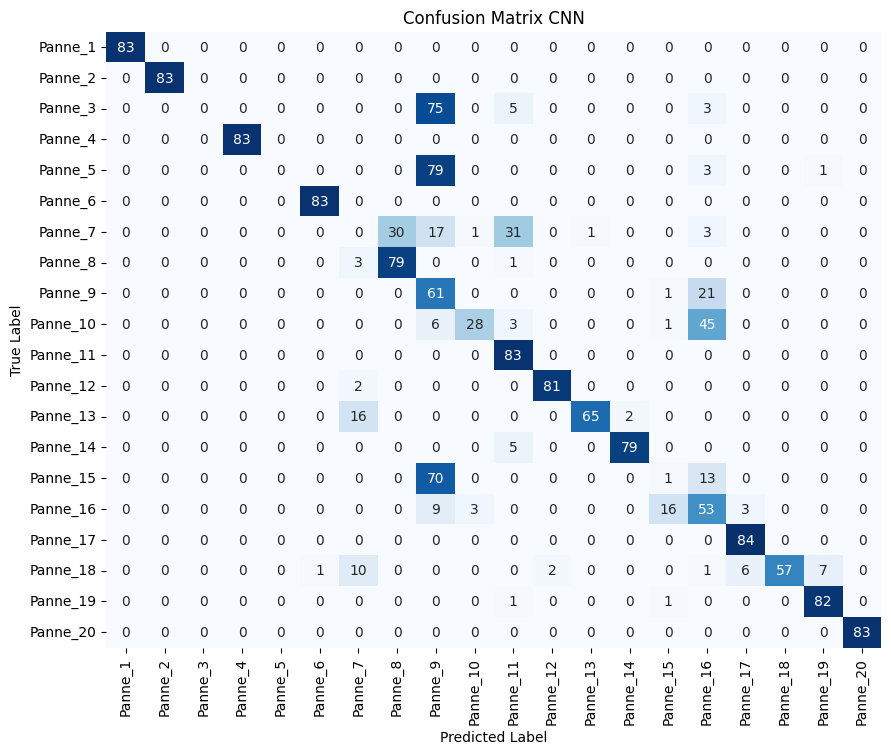

array([13,  8, 14, ..., 16, 17, 18])

In [36]:
eval_test(X_test, y_test)

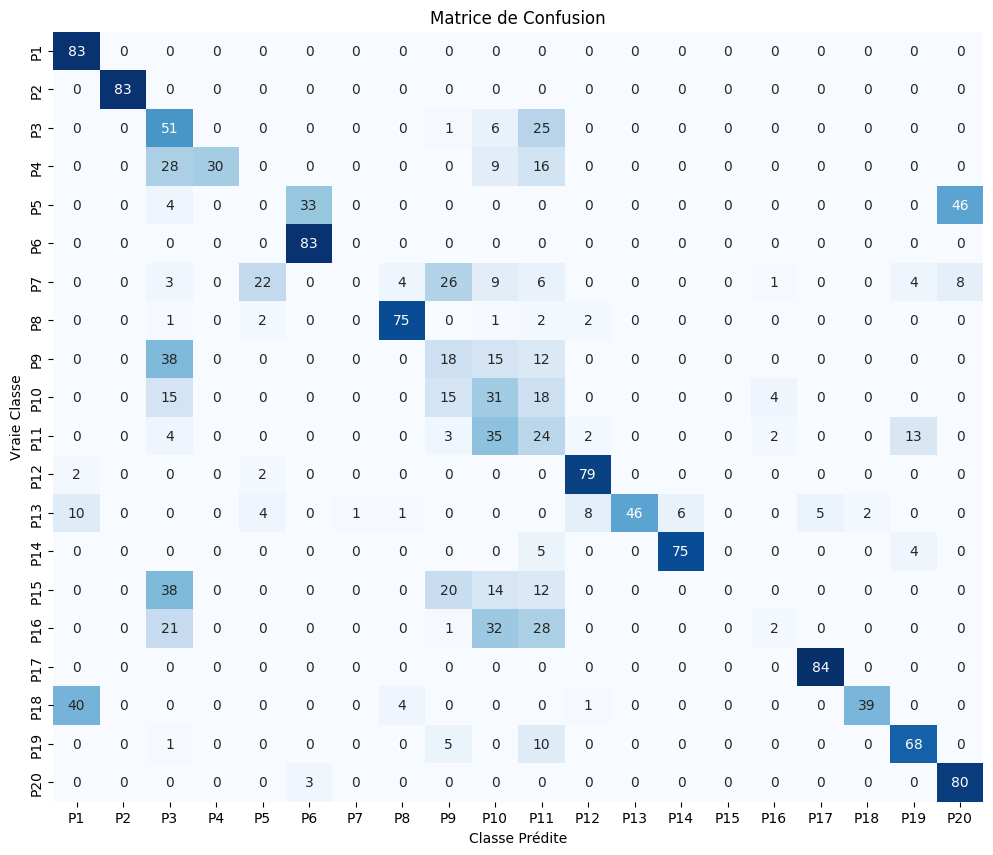


VISUALISATIONS TEMPORELLES
Métadonnées générées pour 1666 séquences.
Nombre de simulations simulées : 33
Affichage de 3 exemples...


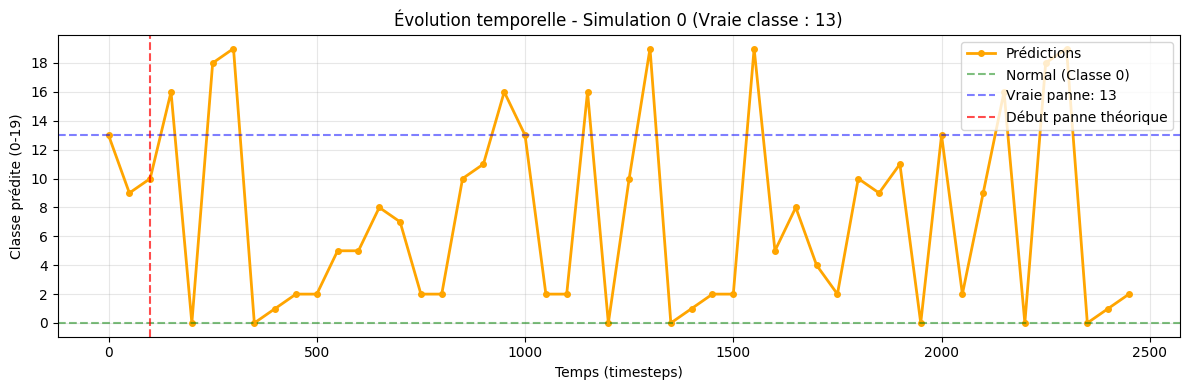


Simulation 0:
  Vraie panne : Type 13
  Détectée à  : timestep 0


NameError: name 'Counter' is not defined

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[f"P{i+1}" for i in range(20)],
            yticklabels=[f"P{i+1}" for i in range(20)])
plt.xlabel('Classe Prédite')
plt.ylabel('Vraie Classe')
plt.title('Matrice de Confusion')
plt.show()
# ====================================
# 4. VISUALISATION TEMPORELLE (NOUVEAU)
# ====================================
print("\n" + "="*50)
print("VISUALISATIONS TEMPORELLES")
print("="*50)
# --- PRÉPARATION DES DONNÉES POUR LA VISUALISATION ---
# 1. On aligne les noms de variables
predicted_classes = y_pred
# On convertit y_test_seq en numpy array pour un accès facile par index
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
# 2. Génération de métadonnées (IMPORTANT)
# Comme le script d'origine ne fournit pas 'test_metadata', nous le reconstruisons ici.
# On suppose ici que les données de test sont des blocs continus.
# On va grouper les données par blocs de 50 séquences pour simuler des "Runs".
sequences_per_sim = 50
test_metadata = []
for i in range(len(y_test)):
    # On crée un faux ID de simulation toutes les 50 séquences
    sim_id = i // sequences_per_sim
    # Le temps est relatif au début du bloc
    timestep = (i % sequences_per_sim) * n_time
    test_metadata.append({
        'sim_idx': sim_id,
        'start_time': timestep
    })
print(f"Métadonnées générées pour {len(predicted_classes)} séquences.")
print(f"Nombre de simulations simulées : {len(y_test) // sequences_per_sim}")
# --- FONCTION DE VISUALISATION ---
def visualize_temporal_predictions(sim_idx):
    """
    Visualise les prédictions temporelles pour une simulation donnée.
    """
    # Récupérer les indices correspondant à cette simulation
    sim_windows = [i for i, meta in enumerate(test_metadata)
                   if meta['sim_idx'] == sim_idx]
    if not sim_windows:
        print(f"Erreur : Aucune donnée trouvée pour la simulation {sim_idx}")
        return
    times = [test_metadata[i]['start_time'] for i in sim_windows]
    preds = predicted_classes[sim_windows]
    # On récupère le vrai label du premier élément de la fenêtre
    # (On suppose que le label est constant durant la simulation)
    true_label = y_test_array[sim_windows[0]]
    plt.figure(figsize=(12, 4))
    # Courbe des prédictions
    plt.plot(times, preds, marker='o', linewidth=2, markersize=4, label='Prédictions', color='orange')
    # Lignes de référence
    plt.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Normal (Classe 0)')
    if true_label != 0:
        plt.axhline(y=true_label, color='blue', linestyle='--', alpha=0.5, label=f'Vraie panne: {true_label}')
    # Marqueur arbitraire de début de panne (à ajuster selon vos vraies données)
    # Ici on met 100 comme exemple si la simulation fait ~500 timesteps
    plt.axvline(x=100, color='red', linestyle='--', alpha=0.7, label='Début panne théorique')
    plt.xlabel('Temps (timesteps)')
    plt.ylabel('Classe prédite (0-19)')
    plt.yticks(range(0, 20, 2)) # Un tick toutes les 2 classes pour lisibilité
    plt.title(f'Évolution temporelle - Simulation {sim_idx} (Vraie classe : {true_label})')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # --- Statistiques de détection ---
    fault_detected_at = None
    # On cherche le premier moment où la prédiction n'est pas 0 (Normal)
    for t, pred in zip(times, preds):
        if pred != 0:
            fault_detected_at = t
            break
    print(f"\nSimulation {sim_idx}:")
    print(f"  Vraie panne : Type {true_label}")
    # Note : Le 'Début réel' à 100 est une hypothèse pour l'affichage ici
    print(f"  Détectée à  : timestep {fault_detected_at if fault_detected_at is not None else 'Non détectée'}")
    if fault_detected_at is not None and true_label != 0:
        # Analyse post-détection
        preds_after_fault = [p for t, p in zip(times, preds) if t >= fault_detected_at and p != 0]
        if preds_after_fault:
            most_common = Counter(preds_after_fault).most_common(1)[0]
            print(f"  Classe majoritaire après détection : {most_common[0]} ({most_common[1]} fois)")
            if most_common[0] == true_label:
                print("  => Diagnostic CORRECT")
            else:
                print("  => Diagnostic INCORRECT (Confusion)")
# --- EXÉCUTION DES EXEMPLES ---
# On cherche quelques index de simulations intéressantes à visualiser
# On essaie de trouver une simulation avec une panne (label != 0)
found_faulty_sim = False
unique_sims = sorted(list(set(m['sim_idx'] for m in test_metadata)))
print("Affichage de 3 exemples...")
count = 0
for sim_idx in unique_sims:
    # Vérifier le label de cette sim
    idx_first = [i for i, m in enumerate(test_metadata) if m['sim_idx'] == sim_idx][0]
    label = y_test_array[idx_first]
    # On affiche si c'est une panne (pour l'intérêt visuel) ou la première sim
    if label != 0 or count == 0:
        visualize_temporal_predictions(sim_idx)
        count += 1
    if count >= 3:
        break


In [12]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np # Added numpy import

# Define n_time and n_feat based on the previous cell's context (WBB-ekr1GjHT)
# From kernel state: timesteps_per_sequence = 500, num_features = 52
n_time = 10
n_feat = 52

# Adjust y_train and y_test to match the number of sequences for the LSTM output.
# Assuming `faultNumber` is constant within a sequence and we need one label per sequence.
# Also, adjust labels to be 0-indexed for sparse_categorical_crossentropy (from 1-20 to 0-19).
# The y_train and y_test in kernel state are already trimmed Series from the last fold.
y_train_seq = y_train.iloc[::n_time] - 1
y_test_seq = y_test.iloc[::n_time] - 1

print("\n" + "="*60)
print("ENTRAÎNEMENT DU MODÈLE LSTM")
print("="*60)

model = keras.Sequential([
    layers.Input(shape=(n_time, n_feat)),
    layers.LSTM(128, return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(20, activation='softmax')  # 20 classes (0-19)
])

model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_final, y_train_seq, # Use y_train_seq
    validation_data=(X_test_final, y_test_seq), # Use y_test_seq
    epochs=50,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
    ]
)
# ====================================
# 4. ÉVALUATION
# ====================================

test_loss, test_acc = model.evaluate(X_test_final, y_test_seq, verbose=0) # Use y_test_seq
print(f"\nTEST ACCURACY : {test_acc:.4f}")

y_prob = model.predict(X_test_final, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Adjust class_labels and class_names for 0-indexed labels and proper display
class_labels = sorted(np.unique(y_test_seq)) # These will be 0-19
class_names = [f"Panne_{label+1}" for label in class_labels] # Map 0->Panne_1, 1->Panne_2, etc.

from sklearn.metrics import classification_report
print("\n" + classification_report(
    y_test_seq, y_pred, # Use y_test_seq
    labels=class_labels,
    target_names=class_names,
    zero_division=0
))

# Sauvegarde
model.save("lstm_fault_classifier_20classes.keras")
print("\n✓ Modèle sauvegardé : lstm_fault_classifier_20classes.keras")


ENTRAÎNEMENT DU MODÈLE LSTM


2025-12-09 11:07:22.715901: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-12-09 11:07:22.716087: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-09 11:07:22.716096: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-12-09 11:07:22.716349: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-09 11:07:22.716686: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


ValueError: Data cardinality is ambiguous:
  x sizes: 8333
  y sizes: 41665
Make sure all arrays contain the same number of samples.

Confusion Matrix:
 [[83  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 83  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0 10  0  0  0  0  0 36  0  0  0  0  4]
 [ 0  0  0 83  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 83  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 83  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 83  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 68  0  0  0 13  0  0  0  1  0  0  0  1]
 [ 0  0 25  0  0  0  0  0 36  1  0  0  0  0 18  0  0  0  0  3]
 [ 0  0 21  0  0  0  0  0 23  2  0  0  0  0 31  2  0  0  0  4]
 [ 0  0  5  5  0  0  0  0  9  0 11  9  2  1 17  9  0  0  3 12]
 [ 0  0  0  0  0  0  0  3  0  1  0 77  1  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0 82  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  4  0  0 80  0  0  0  0  0  0]
 [ 0  0 24  0  0  0  0  0 40  1  0  0  0  0 16  0  0  0  0  3]
 [ 0  0  6  0  0  0  0  0 14  0  5  

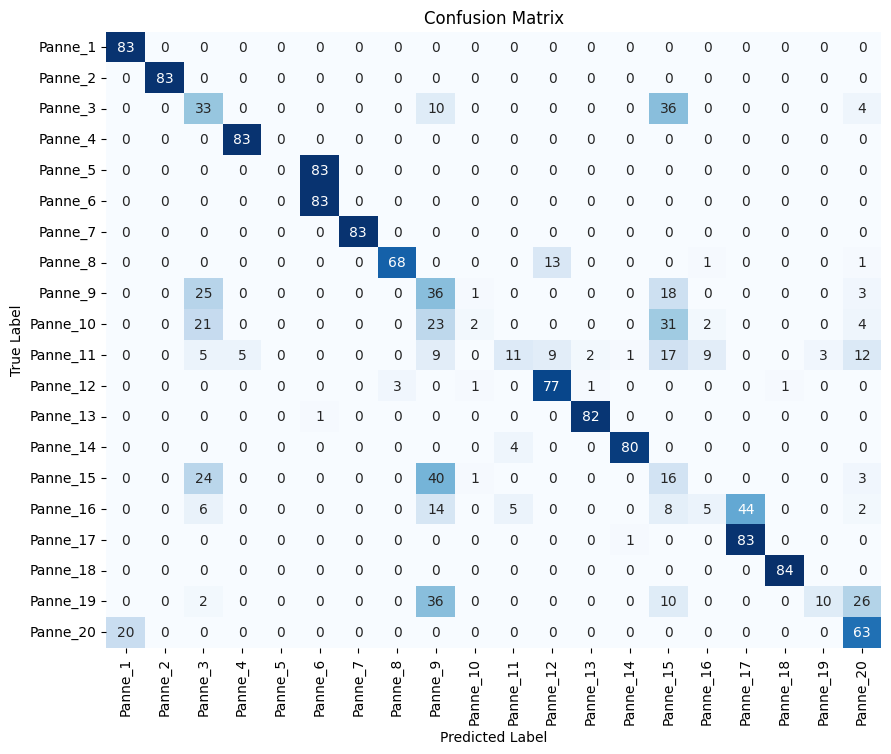

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_seq, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[f"Panne_{i+1}" for i in range(20)],
            yticklabels=[f"Panne_{i+1}" for i in range(20)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()